<a href="https://colab.research.google.com/github/Davemtz192/devops-aws-fase1/blob/main/Actividad_4_2_y_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import math
import matplotlib.pyplot as plt

# Definimos un rango de n_qubits de 2 a 10 (tal como sugiere la guía)
rango_qubits = list(range(2, 11))
lista_N = []
pasos_clasicos = []
iteraciones_grover = []

for n in rango_qubits:
    N = 2**n
    lista_N.append(N)

    # 1. Búsqueda clásica (Caso promedio: N / 2)
    pasos_clasicos.append(N / 2)

    # 2. Algoritmo de Grover (Cálculo teórico de iteraciones óptimas: floor((pi/4) * sqrt(N)))
    optimas = math.floor(math.pi / 4 * math.sqrt(N))
    iteraciones_grover.append(optimas)

print("Espacios de búsqueda (N):", lista_N)
print("Pasos clásicos (promedio):", pasos_clasicos)
print("Iteraciones de Grover:", iteraciones_grover)

Espacios de búsqueda (N): [4, 8, 16, 32, 64, 128, 256, 512, 1024]
Pasos clásicos (promedio): [2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0]
Iteraciones de Grover: [1, 2, 3, 4, 6, 8, 12, 17, 25]


In [7]:
!pip install qiskit qiskit-aer ipywidgets

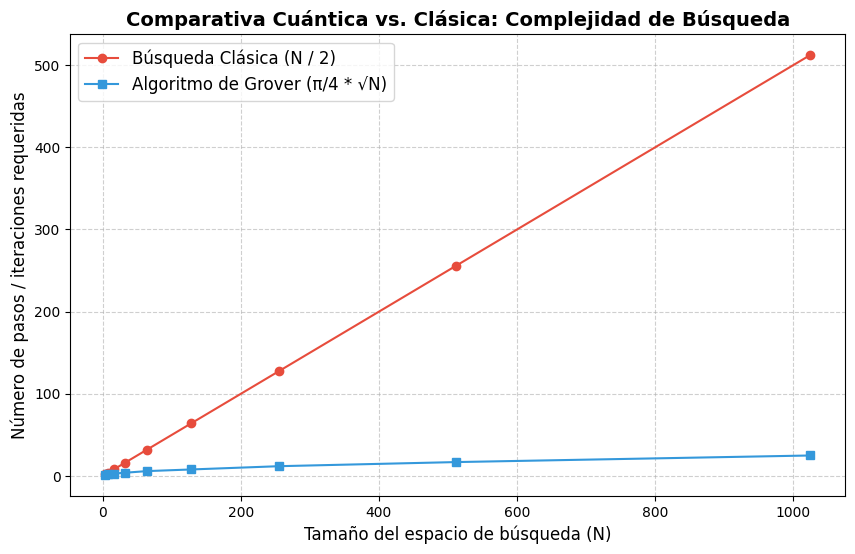

In [8]:
plt.figure(figsize=(10, 6))

# Trazar curva clásica
plt.plot(lista_N, pasos_clasicos, marker='o', linestyle='-', color='#e74c3c', label='Búsqueda Clásica (N / 2)')

# Trazar curva cuántica (Grover)
plt.plot(lista_N, iteraciones_grover, marker='s', linestyle='-', color='#3498db', label='Algoritmo de Grover (π/4 * √N)')

plt.title('Comparativa Cuántica vs. Clásica: Complejidad de Búsqueda', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño del espacio de búsqueda (N)', fontsize=12)
plt.ylabel('Número de pasos / iteraciones requeridas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

In [12]:
import math
import ipywidgets as widgets
from IPython.display import display, clear_output
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, DiagonalGate
from qiskit.quantum_info import Operator
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

def crear_oraculo(estado_objetivo):
    n = len(estado_objetivo)
    circuito_oraculo = QuantumCircuit(n)
    item_invertido = estado_objetivo[::-1]

    for idx, bit in enumerate(item_invertido):
        if bit == '0':
            circuito_oraculo.x(idx)

    if n > 1:
        circuito_oraculo.h(n - 1)
        circuito_oraculo.mcx(list(range(n - 1)), n - 1)
        circuito_oraculo.h(n - 1)
    else:
        circuito_oraculo.z(0)

    for idx, bit in enumerate(item_invertido):
        if bit == '0':
            circuito_oraculo.x(idx)

    # Uso de Operator para extraer los datos de forma totalmente compatible
    matriz_operador = Operator(circuito_oraculo).data
    matriz_diagonal = DiagonalGate(matriz_operador)
    return matriz_diagonal

def ensamblar_circuito_grover(n_qubits, estado_objetivo, iteraciones):
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))

    if iteraciones > 0:
        oraculo = crear_oraculo(estado_objetivo)
        operador_grover = GroverOperator(oraculo)
        for _ in range(iteraciones):
            qc.compose(operador_grover, inplace=True)

    qc.measure(range(n_qubits), range(n_qubits))
    return qc

input_qubits = widgets.IntText(value=4, description='n_qubits:', style={'description_width': 'initial'})
input_estado = widgets.Text(value='1011', description='Estado objetivo:', style={'description_width': 'initial'})
boton_ejecutar = widgets.Button(description='Ejecutar Algoritmo', button_style='success', icon='play')
salida_texto = widgets.Output()
salida_graficos = widgets.Output()

def on_button_clicked(b):
    with salida_texto:
        clear_output(wait=True)
        n = input_qubits.value
        estado = input_estado.value.strip()

        if len(estado) != n:
            print(f"Error: La longitud del estado objetivo ('{estado}' tiene {len(estado)} bits) debe coincidir exactamente con n_qubits ({n}).")
            return

        N = 2**n
        iteraciones_optimas = math.floor(math.pi / 4 * math.sqrt(N))
        print(f"Espacio de búsqueda total (N): {N} combinaciones.")
        print(f"Buscando el estado marcado: |{estado}>")
        print(f"Iteraciones óptimas de Grover calculadas: {iteraciones_optimas}")
        print("-" * 50)

    with salida_graficos:
        clear_output(wait=True)
        if len(estado) != n:
            return

        N = 2**n
        iteraciones_optimas = math.floor(math.pi / 4 * math.sqrt(N))

        circuito = ensamblar_circuito_grover(n, estado, iteraciones_optimas)
        print("Arquitectura del Circuito Cuántico:")
        display(circuito.draw(output='mpl'))

        sampler = StatevectorSampler()
        job = sampler.run([circuito])
        resultado = job.result()
        pub_resultado = resultado[0]

        if hasattr(pub_resultado.data, 'meas'):
            conteos = pub_resultado.data.meas.get_counts()
        else:
            clave_creg = list(pub_resultado.data.keys())[0]
            conteos = getattr(pub_resultado.data, clave_creg).get_counts()

        total_shots = sum(conteos.values())
        aciertos = conteos.get(estado, 0)
        probabilidad = (aciertos / total_shots) * 100
        print(f"\nProbabilidad final obtenida para el estado |{estado}>: {probabilidad:.2f}% ({aciertos} conteos)")

        display(plot_histogram([conteos], legend=[f'Grover ({iteraciones_optimas} iteraciones)']))

boton_ejecutar.on_click(on_button_clicked)
display(widgets.VBox([input_qubits, input_estado, boton_ejecutar, salida_texto, salida_graficos]))